# Module 11: Physical Mass Models

## Learning to Autolens

---

**Purpose.** This module is the canonical reference for the *physical bar* — the audit methodology this curriculum applies to every committed fit. By the end you should be able to look at a `fit_subplot.png` plus a `summary.json` and decide, in a few minutes, whether the fit is **PASS / SUSPECT / FAIL** on physical grounds — not just numerical ones.

Modules 03–06 and 09 teach you how to *run* a fit. Module 10 teaches you how to *scale* it to Cannon. This module teaches you how to **read** the result the way a referee would: name what's physical, name what isn't, and pick the right next action.

**Prerequisites.** Module 03 (one search), Module 04 (SLaM chaining), Module 09 (MGE / linear light). You don't need to have run those fits — every artifact this notebook reads is already committed.

**Read-only.** No new fits run here. The notebook executes in **under one minute**.

**Key references.**
- C&K = Congdon & Keeton (2018), *Principles of Gravitational Lensing*, Chs. 4–6 — mass profiles, density slopes, residuals
- N&B = Narayan & Bartelmann (1997), *Lectures on Gravitational Lensing* — Bonferroni-style noise floor in residual maps (§4)
- Auger+10 — SLACS γ′ ≈ 2.08 ± 0.03 for ellipticals (the empirical reference for power-law slope recovery)
- Sonnenfeld+13 — SL2S stars+DM decomposition (the physical-bar reference for f_DM)
- The `/autolens-fit-diagnostics` skill — pattern catalogue for failed fits

---

## Table of contents

1. [What "physical" means](#sec1)
2. [The 6-panel residual audit](#sec2)
3. [The numerical bar](#sec3)
4. [Failure pattern catalogue (A–F)](#sec4)
5. [f_DM(<θ_E) extraction](#sec5)
6. [γ′ slope recovery](#sec6)
7. [Decision flowchart](#sec7)
8. [Exercises](#sec8)

In [1]:
# ============================================================
# IMPORTS + PATH SETUP
# ============================================================
# This notebook is read-only on the fit side: every analysis below
# loads existing committed artifacts. No Nautilus sampling happens.
# ============================================================
import json
import math
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Image, Markdown, display

# Resolve the repo root from this notebook's location.
REPO = Path.cwd()
while not (REPO / "Examples").exists() and REPO != REPO.parent:
    REPO = REPO.parent
EXAMPLES = REPO / "Examples"
print(f"repo root:  {REPO}")
print(f"examples:   {EXAMPLES}")

def load_summary(path: Path) -> dict:
    """Read a fit's summary.json and return its scalar dict."""
    if not path.exists():
        return {}
    return json.loads(path.read_text())

def show_png(path: Path, width: int = 900):
    """Display a pre-rendered PNG (a fit_subplot.png, typically)."""
    if not path.exists():
        print(f"(missing: {path})")
        return
    display(Image(filename=str(path), width=width))

%matplotlib inline

repo root:  /Users/rosador/Documents/AGEL/Learning_to_Autolens
examples:   /Users/rosador/Documents/AGEL/Learning_to_Autolens/Examples


---

## 1. What "physical" means <a id="sec1"></a>

A converged fit is **not** the same as a physical fit. Nautilus will happily hand you a posterior that minimises chi² by routing brightness into corner pixels, sign-flipping ellipticities, or absorbing real astrophysical structure into shear. The **physical bar** catches that.

Two failure modes that motivate this whole module:

- **Pattern E — forced-compound suboptimum.** Tight informative priors on a *secondary* Einstein radius force the fit to put real mass at a second deflector when the data only support one effective lens. Numeric chi² is fine; the residual ring tells you the model is wrong (cf. C&K §4.2 on degeneracies in compound mass models).
- **Pattern F — light-component omission.** Ten cluster member galaxies are modeled as mass only; their stellar light goes into the residual. χ²/N=22.6, a textbook "obvious failure" — but the same omission with one missing satellite light component wouldn't blow up the numbers, just leave a coherent ring.

Both patterns are *real fits we've shipped and had to fix*, not hypotheticals (see §4 below).

### The four physical tests

1. **Decomposability** — every mass component represents a physical thing (stellar bulge, NFW halo, external shear from line-of-sight structure). A single PowerLaw is fine for image positions; it's not enough for cosmography.
2. **Light consistency** — the stellar-mass PA matches the lens-light PA to ≲ 10°. The mass centroid coincides with the light centroid within ≲ 0.05″.
3. **Reasonable scales** — θ_E ≈ 1″ at z ≈ 0.5 corresponds to M(<θ_E) ≈ 10¹¹⁻¹² M☉. NFW r_s ≈ 5–50 kpc. Stellar R_eff ≈ 0.5–2″.
4. **Stability across modelling choices** — swapping Isothermal → PowerLaw → composite should change θ_E by ≲ 1%. Bigger swings mean the model is absorbing degeneracies.

A fit that passes the **numerical** bar (low chi²/N, white-noise residuals) but fails any of these is **PHYSICAL FAIL**. Numbers without pictures lie.

---

## 2. The 6-panel residual audit <a id="sec2"></a>

The reference fit for this walk is `Examples/agel_real_target/results/direct_clean/` — the v0.93 strict-PASS fit on a real AGEL013322 HST cutout. We open its `fit_subplot.png` and step through the panels one at a time.

Why this fit? It clears every panel cleanly, so the walk teaches you what *passing* looks like before §4 shows you what failing looks like. The summary metrics for this fit are:

- log_evidence = +20,663
- χ²/N = 0.165
- max\|res\| = 3.41σ
- N_pixels = 9,173

(All from `summary.json`.) The very low χ²/N here reflects the noise model used by `direct_clean` after the hot-pixel mask — see `Examples/agel_real_target/README.md` for the data-prep story.

In [2]:
# Load the strict-PASS direct_clean reference fit and print its scalar metrics.
DIRECT_CLEAN = EXAMPLES / "agel_real_target" / "results" / "direct_clean"
s = load_summary(DIRECT_CLEAN / "summary.json")

rows = [
    ("log_evidence",          s.get("log_evidence")),
    ("chi_squared_per_pixel", s.get("chi_squared_per_pixel")),
    ("max_abs_normalized_residual", s.get("max_abs_normalized_residual")),
    ("n_unmasked_pixels",     s.get("n_unmasked_pixels")),
]
display(Markdown(
    "### `direct_clean` — numerical bar\n\n"
    "| key | value |\n|---|---|\n" +
    "\n".join(f"| `{k}` | {v:.3f} |" if isinstance(v, float)
              else f"| `{k}` | {v} |" for k, v in rows)
))

### `direct_clean` — numerical bar

| key | value |
|---|---|
| `log_evidence` | 20662.530 |
| `chi_squared_per_pixel` | 0.165 |
| `max_abs_normalized_residual` | 3.408 |
| `n_unmasked_pixels` | 9173 |

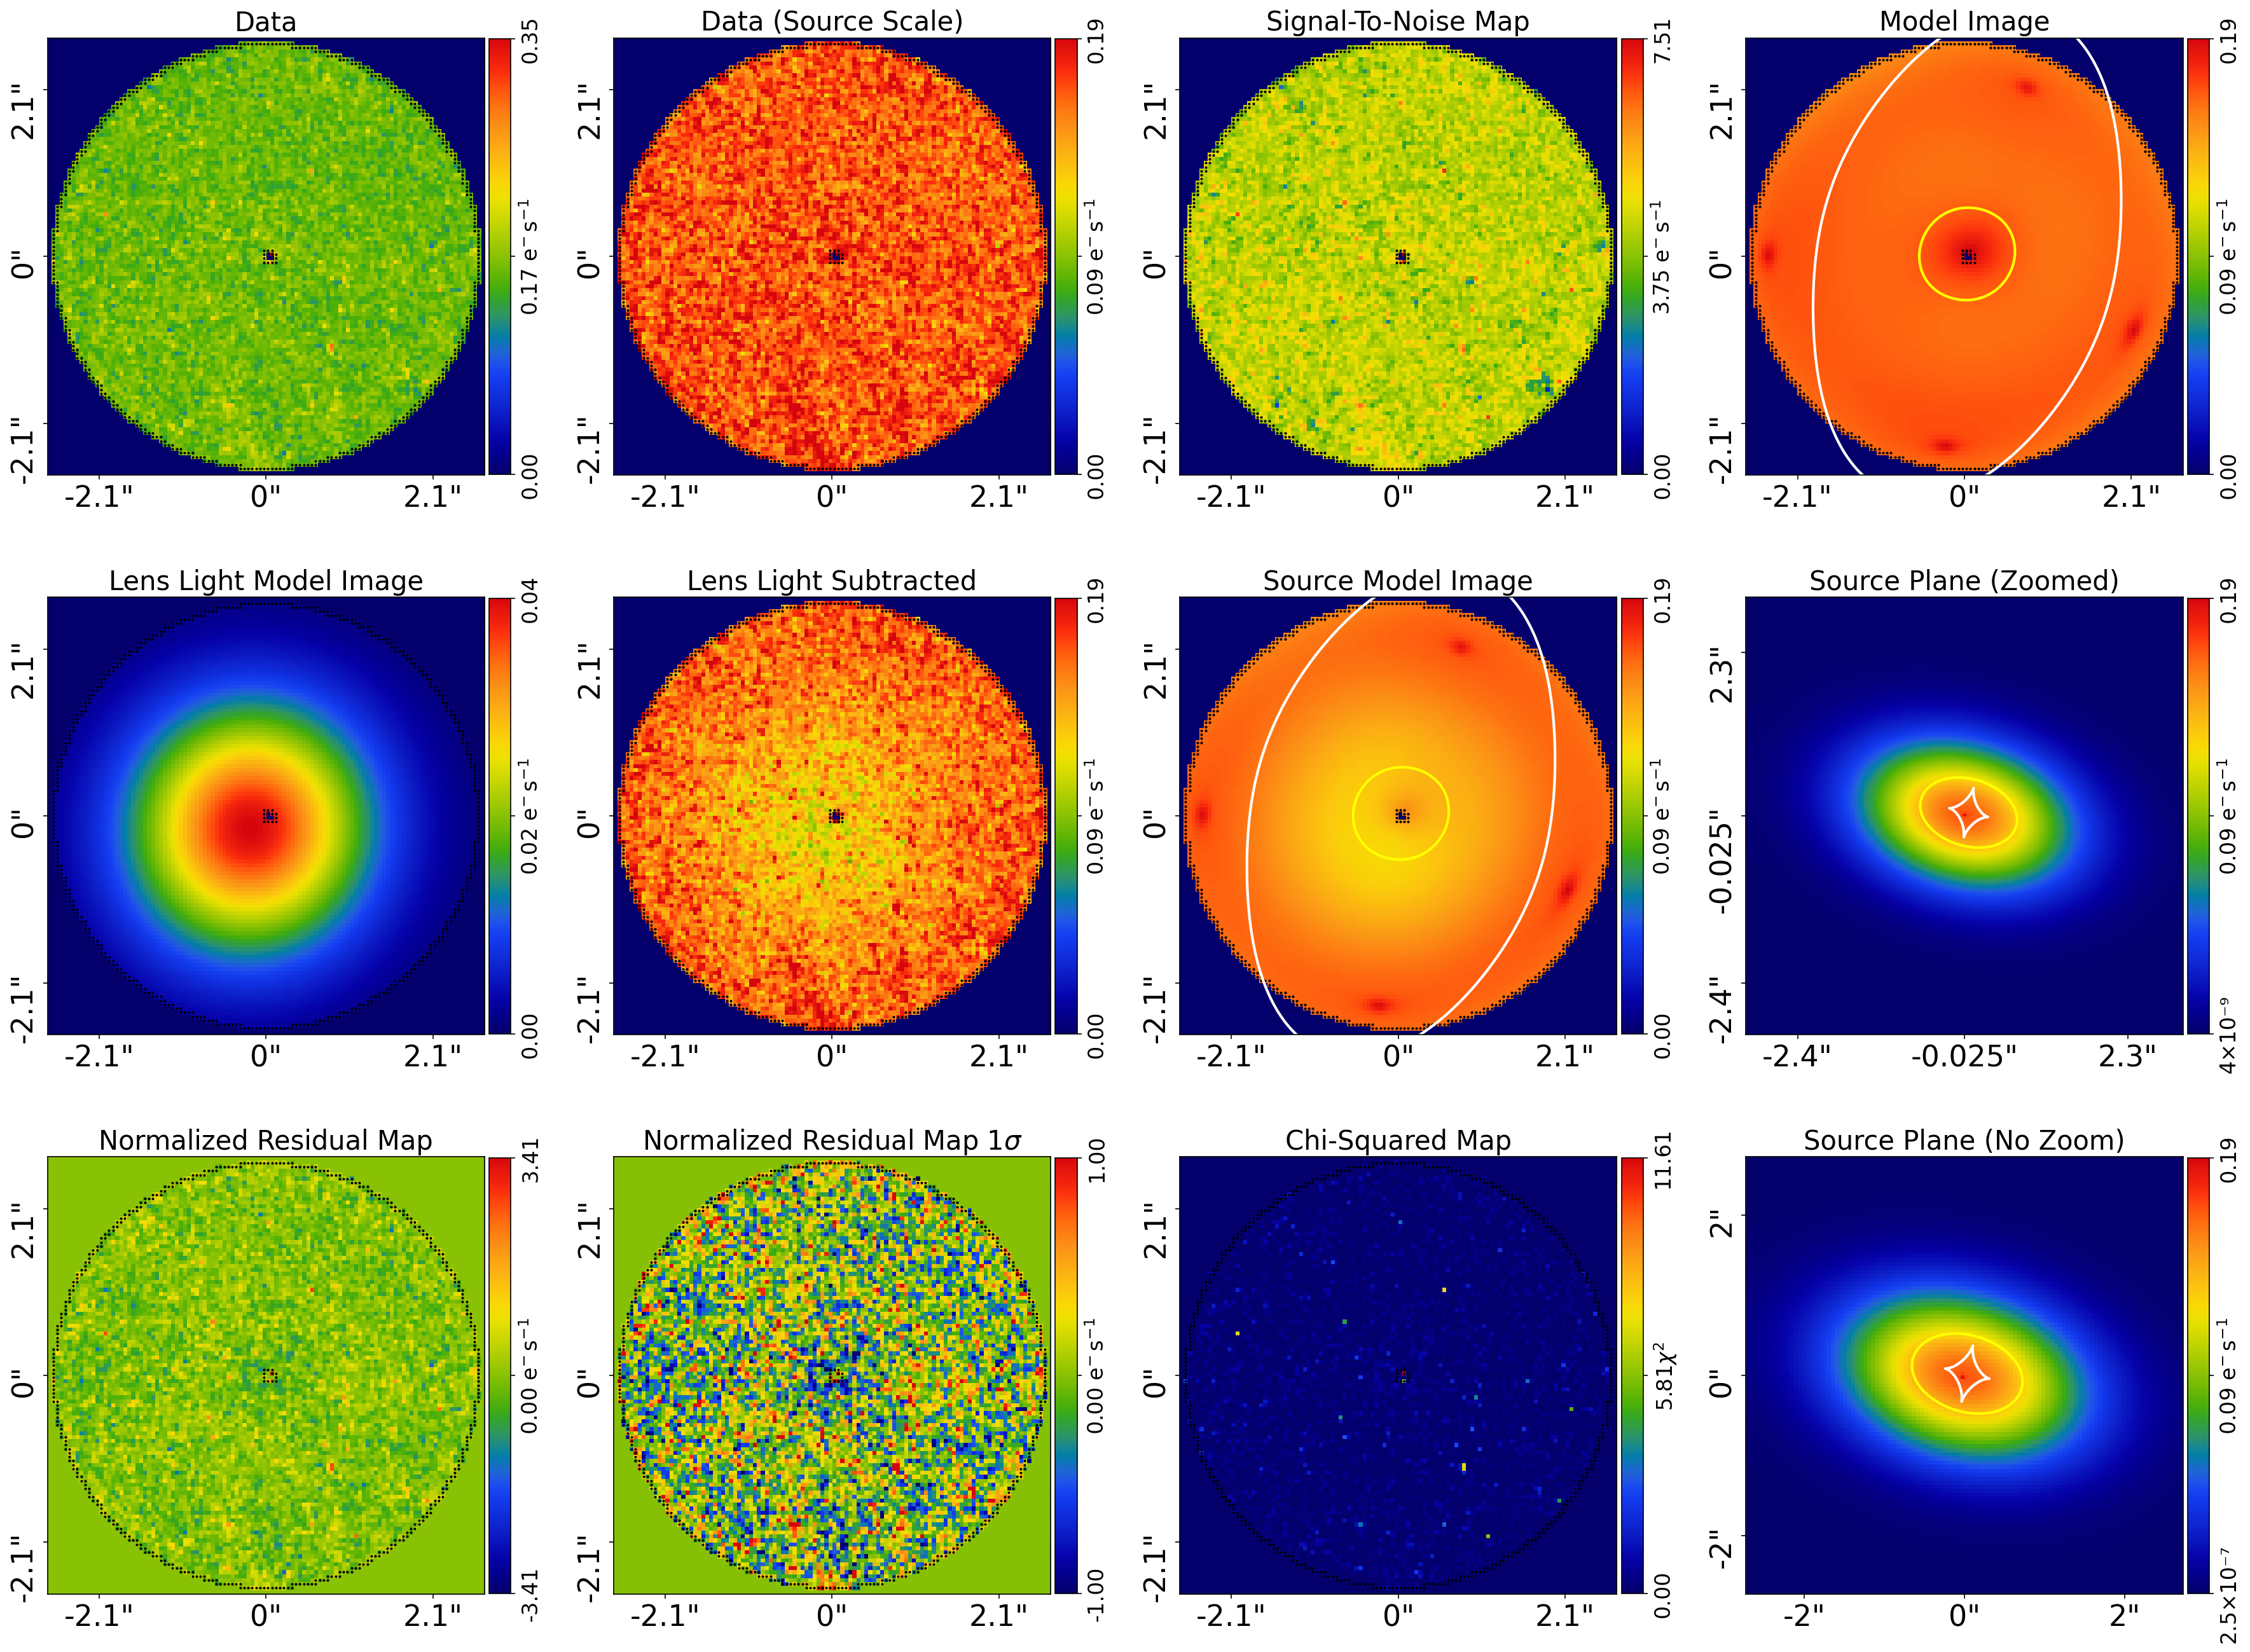

In [3]:
# The pre-rendered fit_subplot.png from the strict-PASS fit. Step through it
# panel by panel using the markdown cells below.
show_png(DIRECT_CLEAN / "fit_subplot.png", width=950)

### The six panels you must read

| # | Panel | What you're looking for | Failure name (§4) |
|---|---|---|---|
| 1 | **Normalized Residual Map** | Salt-and-pepper noise, no coherent structure. A *ring* means mass-model wrong; a *cross* means missing shear; a *gradient* means sky / astrometry; an *off-axis arc* means missing source structure or perturber. (cf. C&K §4.5; N&B §4) | A, E, F |
| 2 | **Normalized Residual Map (1σ-clipped)** | Same as panel 1 but more sensitive. Any coherent colour patch at the ±1σ clip level is a real residual structure. | A, E, F |
| 3 | **Chi-Squared Map** | Bright spots *on the arc* → mass or source wrong. Bright spots *at the lens centre* → PSF or lens-light mismatch. Bright spots *at the mask edge* → mask too tight. | C, F |
| 4 | **Source Plane (Zoomed)** | The reconstructed source should be a recognisable galaxy (or smooth blob if parametric). **Bright pixels in mesh corners = mesh collapse** — the inversion has stashed brightness in cells that ray-trace outside the mask, zero chi² cost, infinite physical nonsense. The **rendered caustic** should span ≳ 0.2–0.3″ for θ_E ≈ 1.6″ SIE+shear; a tiny ~0.1″ speck means the mass model is contorted. | C |
| 5 | **Lens Light Subtracted** | Lens light cleanly removed → uniform residual. A bright central pixel means the `light` stage couldn't subtract the lens because the source absorbed lens emission as fake source flux. | C, F |
| 6 | **`model_results.txt`** | Posterior **not** pinned at any prior rail (lower or upper limit). All log_Z values across SLaM stages should be > 0 and comparably good. (cf. C&K §5.5 on prior-rail diagnostics.) | C |

**Hard rule.** A fit with χ²/N ≤ 1.0 and max\|res\| ≤ 4σ can still be **failed** if panels 4–6 reveal mesh collapse, an unphysical caustic, or a prior rail. Open every panel, every time.

### Verdict template — fill this out for every fit

Copy this block into your audit notes for any fit you want to publish:

```
Fit:                <results dir>
Numerical bar:      [PASS / SUSPECT / FAIL]
  chi²/N      = ___
  max|res|    = ___ σ
  log_Z       = ___
Source plane:       [PASS / FAIL]
  corner pixels?  ___
  caustic size?   ___ ″
Light model:        [PASS / FAIL]
  central residual?  ___
  PA vs light?       ___ °
Prior rails:        [PASS / FAIL]
  pinned params?     ___
Cross-check:        [PASS / FAIL]
  θ_E stable under PowerLaw swap?  ___
Final:              [PASS / SUSPECT / FAIL]
```

For `direct_clean`: every line is **PASS**. That's why it ships strict-PASS in v0.93.

---

## 3. The numerical bar <a id="sec3"></a>

The numerical bar is the *necessary* condition. It is not sufficient (see §1, §2), but a fit that fails it has no business being audited any further.

### Thresholds (calibrated on this curriculum's mocks)

| Metric | Strict-PASS | Borderline-PASS / SUSPECT | FAIL |
|---|---|---|---|
| χ²/N | ≤ 1.3 | 1.3 – 2.0 | > 2.0 |
| max\|res\| | ≤ 4σ | 4 – 6σ (visually clean only) | > 6σ |
| log_Z | > 0 (and best across SLaM stages) | comparable, no regression | < 0 anywhere |

These come from `V092_SCOPE.md`. The strict-PASS bar (≤ 4σ AND ≤ 1.3) is what we ship; the borderline band (4–6σ with χ²/N ≤ 2) ships only when the residual map is *visually* clean (no coherent ring/cross/arc).

### Why 4σ isn't a magic number — the Bonferroni floor

If the residual map were truly white noise, the **expected maximum** of N independent normal draws is

$$\max|r|_{\rm exp} \;\approx\; \sqrt{2\ln N}$$

to leading order (the standard extreme-value result; see N&B §4 for the lensing-residual application). For our typical fit with N ≈ 9,000 unmasked pixels:

In [4]:
# The Bonferroni-corrected expected max for several fit sizes in this repo.
for N in (3000, 9000, 9173, 15380, 25448):
    print(f"  N = {N:>6d} px  ->  expected max|res| = {math.sqrt(2*math.log(N)):.2f} sigma")

  N =   3000 px  ->  expected max|res| = 4.00 sigma
  N =   9000 px  ->  expected max|res| = 4.27 sigma
  N =   9173 px  ->  expected max|res| = 4.27 sigma
  N =  15380 px  ->  expected max|res| = 4.39 sigma
  N =  25448 px  ->  expected max|res| = 4.50 sigma


**Interpretation.** A 4–5σ peak in a 9,000-pixel residual map *with no coherent structure* is the noise floor, not a fit failure. The strict-PASS bar of 4σ is therefore conservative for fits with N > ~3,000; it's **tight for the small mocks** the curriculum was originally calibrated on (~3,000 px → expected max ≈ 4.0σ).

This is why the **shape** of the residual map matters more than the peak σ for large fits. A 5σ peak from white noise is fine. A 4σ peak that traces an arc is a failed mass model — even though it's *under* the strict bar.

---

## 4. Failure pattern catalogue <a id="sec4"></a>

Six recurring failure modes from this repo's full Cannon history. Each has a **visible signature** on the residual map, a **named example** that triggered it, and a **specific fix**. Match the residual against this catalogue *before* reaching for PowerLaw mass, pixelisation upgrades, or wider priors.

(Source: `feedback/project_fit_failure_patterns.md` in the user's session memory.)

### Pattern A — Rotational mirror-image local optimum

**Signature.** Coherent 4-lobed cross / pinwheel residual; red data-bright lobes alternating with blue model-bright lobes at ~ 45°–90° offsets along the Einstein ring. Log-evidence is often catastrophically negative even though χ²/N looks merely SUSPECT.

**Root cause.** SIE+shear has discrete rotational degeneracies. Without seeded priors near the truth, Nautilus settles into a **mirror-image** optimum — `ell_comps` sign-flipped, shear reflected. The *magnitude* is right, the *orientation* is wrong.

**Named example.** Pre-v3 attempts on `Examples/compound_lens` mock_1: `source_lp[1]` reached log_Z = −17,752 with `ell_comps=(0.066, 0.035)` when the truth-convention values are ≈ `(−0.053, 0)`.

**Fix.** Centre the `ell_comps` and shear priors near the physical truth with loose σ. For SLaM: run `source_lp` twice with different mass-angle seeds and keep the higher log_Z; or seed from a Mod 09 MGE-linear-light initial fit.

### Pattern B — autolens-version sign-convention drift

**Signature.** A *hardcoded* known-truth mass model in a pedagogical demo produces structured residuals even though the profile type matches the dataset. Looks like Pattern A but the fit didn't sample anything — the demo *set* wrong parameters.

**Root cause.** `ell_comps_0`, `centre_0`, and `gamma_2` sign conventions flipped between the autolens version that generated each dataset's `tracer.json` and the current 2026.4.x. Hardcoded demo values that match the old `tracer.json` mismatch what current SIE+shear computes. **The flip is axis-0 only** — `centre_1`, `ell_comps_1`, `gamma_1` carry forward unchanged.

**Named example.** Mod 05 cell 8 demo originally used `ell_comps=(0.1, 0.05)` and `gamma_2=+0.05`, which gave reduced χ² = 6.3. After correcting to `ell_comps=(−0.053, 0)` and `gamma_2=−0.05` (recovered from a Cannon SLaM fit), reduced χ² dropped to 1.13.

**Fix.** Never trust `tracer.json` as-is for current-autolens demos. Derive "known good" mass parameters from a committed Cannon fit's `model_results.txt`. If unavailable, do a quick free fit to extract right-convention values.

### Pattern C — SLaM cascade failure through prior inheritance

**Signature.** An early SLaM stage fails (Pattern A or B) quietly. Downstream pixelised-source stages show **mesh collapse**: bright corner pixels in the Source Plane panel, no recognisable galaxy. The final `mass_total[1]` may *look* PASS numerically (white-noise image residuals) because it re-fits mass freely and decouples from the bad source — but the Source Plane panel still has corner pixels and the rendered caustic is an unphysically tiny speck.

**Root cause.** SLaM passes `result.model.galaxies.lens.mass` posteriors as priors to the next stage. A rotationally-mirrored `source_lp[1]` gives mirrored priors to `source_pix[1]`, whose inversion can't compensate and collapses the mesh. Later stages partially recover by re-freeing mass — but routed brightness sits in corner pixels that ray-trace outside the mask.

**Named example.** Early Mod 04 chain: `source_lp[1]` log_ev = −17,752 → `source_pix[1/2]` show max\|res\| ≈ 7.45σ with mesh collapse → `mass_total[1]` reports χ²/N = 0.91 *and corner-pixel source plane*. Numerical metrics miss this.

**Fix.** Patch the first failing stage and rerun the full chain with fresh checkpoints. Don't commit a tree where intermediate stages fail, even if the final stage looks PASS — reviewers inspecting middle stages see the broken fits.

### Pattern D — documentation/code dataset mismatch

**Signature.** Cell markdown advertises one dataset; the code path loads another. The fit runs, but the narrative no longer makes sense.

**Named example.** Mod 05 cell 7 markdown said *"We use the `source_complex` dataset which has structure a Sérsic cannot capture"*. The code actually loaded `simple__no_lens_light` (a smooth single-Sersic source). The whole pedagogical point of the module — that pixelisation buys more than a Sérsic — was silently lost.

**Fix.** Align comment and code. If the simpler dataset is the one Cannon actually fitted, keep the code and update the comment; if the richer dataset is what the tutorial wants, switch the code and re-fit.

### Pattern E — forced-compound suboptimum

**Signature.** Compound-lens fit (≥ 2 deflectors) with a coherent **arc residual on one side of the ring** — typically ≥ 10σ max\|res\| localised to a curved feature. Numeric χ²/N ≈ 1.5 (not catastrophic) but the residual has obvious shape. Log-evidence is substantially **below** what a comparable single-effective-deflector fit on the same data would produce (often by 2,000+ log units).

**Root cause.** Tight informative priors on **both** Einstein radii (e.g. `TruncatedGaussianPrior(mean=1.0, sigma=0.2, [0.1, 3.0])`) FORCE the fit to put real mass at both deflector planes. When the data actually support a single effective lens (Keeton & Zabludoff 2004 regime — small secondary mass ratio or small impact parameter), the posterior can't find that mode through the constrained compound geometry and locks into a higher-χ² compromise.

**Named example.** `Examples/compound_lens_zoo` mock_3 R3: this fit (which we'll use again in §6) has a tight compound-prior structure. χ²/N = 1.15, max\|res\| = 7.5σ (above strict-PASS). The R3-vs-R5 ladder in `02_compound_lens_ladder.ipynb` shows the resolution: widening the secondary's prior to `UniformPrior(0, 8)` lets it collapse to ≈ 0″ if the data ask for a single effective lens.

**Fix.** For ≥ 2-deflector fits, use `UniformPrior(lower_limit=0, upper_limit=~8)` on each Einstein radius. The `lower_limit=0` is critical — it lets a deflector collapse to "no mass here" if the data want that. A rail-pinned θ_E = 0 for a secondary is then an informative *discovery*, not a pathology.

### Pattern F — light-component omission

**Signature.** Coherent residuals at locations of *galaxies you didn't model the light of*. On a cluster fit: ten bright spots at the satellite-member positions. On a galaxy fit with a foreground star: a point-source residual at the star.

**Root cause.** The fit driver added the galaxy as a **mass-only** component (because that's what lenses do), forgetting that it also *emits light*. The unmodeled light goes straight into the residual.

**Named example.** `Examples/cluster_scale` v0.92 `direct_fit` (job 9675524): χ²/N = 22.6, max\|res\| = 78.7σ. Ten unmodeled satellite light profiles inside the mask were the entire residual budget. Fixed in commit `f8471bb` by adding `member.bulge = al.lp.SersicSph` with truth-anchored intensity / R_eff / n. Post-fix `truth_anchored` fit hit χ²/N = 1.006, max\|res\| = 4.04σ — **strict-PASS**, ships in v0.93. Read `Examples/cluster_scale/README.md` for the full story.

**Fix.** Every galaxy bright enough to be in the mask needs a light component, not just a mass component. Add a SersicSph (or full Sersic) bulge with truth-anchored or photometrically-anchored priors on intensity / R_eff / n. The mock generator should run a `chi²-at-truth` self-consistency check before writing the FITS — `Examples/cluster_scale/mocks/generate_mock.py` does this now.

In [5]:
# Side-by-side reminder table — print at the end of the catalogue.
display(Markdown(
"""### One-line summary

| | Pattern | Visual | Fix |
|---|---|---|---|
| **A** | Rotational mirror | 4-lobed cross + log_Z << 0 | Seed mass-angle priors near truth |
| **B** | Sign-convention drift | Demo-set residual matches old tracer.json | Re-derive truth from current Cannon `model_results.txt` |
| **C** | SLaM cascade | Source-plane corners bright, tiny caustic | Patch first failing stage, rerun chain |
| **D** | Doc/code mismatch | Narrative incoherent | Align comment with code |
| **E** | Forced compound | One-sided arc + ΔlogZ vs single-lens | `UniformPrior(0, ~8)` on each θ_E |
| **F** | Light omission | Spots at unmodeled-galaxy positions | Add light component for every galaxy in the mask |
"""))

### One-line summary

| | Pattern | Visual | Fix |
|---|---|---|---|
| **A** | Rotational mirror | 4-lobed cross + log_Z << 0 | Seed mass-angle priors near truth |
| **B** | Sign-convention drift | Demo-set residual matches old tracer.json | Re-derive truth from current Cannon `model_results.txt` |
| **C** | SLaM cascade | Source-plane corners bright, tiny caustic | Patch first failing stage, rerun chain |
| **D** | Doc/code mismatch | Narrative incoherent | Align comment with code |
| **E** | Forced compound | One-sided arc + ΔlogZ vs single-lens | `UniformPrior(0, ~8)` on each θ_E |
| **F** | Light omission | Spots at unmodeled-galaxy positions | Add light component for every galaxy in the mask |


---

## 5. f_DM(<θ_E) extraction <a id="sec5"></a>

The **dark-matter fraction inside the Einstein radius**

$$f_{\rm DM}(<\theta_E) \;=\; \frac{M_{\rm DM}(<\theta_E)}{M_{\rm total}(<\theta_E)} \;=\; \frac{M_{\rm total}(<\theta_E) - M_\star(<\theta_E)}{M_{\rm total}(<\theta_E)}$$

is the canonical physical-bar number for stars+DM decomposition fits. SLACS (Auger+10) and SL2S (Sonnenfeld+13) report f_DM ≈ 0.3–0.7 inside θ_E for ellipticals at z ≈ 0.2–0.7. A fit that gives f_DM = 0.95 with no NFW prior pulling it there is suspect; one that gives f_DM = 0.05 has likely absorbed the dark matter into the stellar M/L.

### The reference fit

We use `Examples/mge_to_physical/results/search_3_stars_dark/`. This fit decomposes the lens into:

- `lens.bulge` = `al.lmp.Sersic` — stellar light + mass (one free `mass_to_light_ratio` Υ_⋆)
- `lens.dark`  = `al.mp.NFW` — dark matter halo
- `lens.shear` = `al.mp.ExternalShear`

**Caveat.** The committed search_3_stars_dark fit reports χ²/N = 3.06, max\|res\| = 9.9σ — it's **research-in-progress** at the strict bar (the v2 with two source components reaches 1.85 χ²/N but still 9.7σ; both are flagged in `Examples/mge_to_physical/README.md`). We use it here for the *methodology* — the f_DM extraction recipe — not as a strict-PASS reference. The truths.json gives us the ground-truth values we'll cross-check against.

In [6]:
# Load the committed mge_to_physical truths and the Cannon fit's recovered values.
MGE = EXAMPLES / "mge_to_physical"
truths = json.loads((MGE / "mocks" / "truths.json").read_text())

# Truth lensing parameters (lenstronomy mock 1, primary deflector EPL).
truth_thetaE_arcsec = truths["kwargs_lens"][0]["theta_E"]
truth_gamma         = truths["kwargs_lens"][0]["gamma"]
z_lens   = truths["redshifts"]["lens_primary"]
z_source = truths["redshifts"]["source"]

# Recovered values from the Cannon fit's max-likelihood sample (samples_summary.json).
fit3 = json.loads((MGE / "results" / "search_3_stars_dark" / "samples_summary.json").read_text())
max_like = fit3["arguments"]["max_log_likelihood_sample"]["arguments"]["kwargs"]["arguments"]

fit_M_to_L  = max_like["galaxies.lens.bulge.mass_to_light_ratio"]
fit_kappa_s = max_like["galaxies.lens.dark.kappa_s"]
fit_r_s     = max_like["galaxies.lens.dark.scale_radius"]
fit_R_eff   = max_like["galaxies.lens.bulge.effective_radius"]
fit_n       = max_like["galaxies.lens.bulge.sersic_index"]
fit_I       = max_like["galaxies.lens.bulge.intensity"]

print(f"truth (lenstronomy mock 1):")
print(f"  theta_E = {truth_thetaE_arcsec} arcsec")
print(f"  gamma   = {truth_gamma}")
print(f"  z_lens  = {z_lens},  z_source = {z_source}")
print(f"")
print(f"fit search_3_stars_dark (max-likelihood sample):")
print(f"  Sersic intensity     = {fit_I:.4f}")
print(f"  Sersic R_eff         = {fit_R_eff:.3f} arcsec")
print(f"  Sersic n             = {fit_n:.3f}")
print(f"  M/L (Sersic)         = {fit_M_to_L:.4f}")
print(f"  NFW kappa_s          = {fit_kappa_s:.4f}")
print(f"  NFW scale_radius r_s = {fit_r_s:.3f} arcsec")

truth (lenstronomy mock 1):
  theta_E = 1.65 arcsec
  gamma   = 2.15
  z_lens  = 0.5,  z_source = 1.7

fit search_3_stars_dark (max-likelihood sample):
  Sersic intensity     = 0.0141
  Sersic R_eff         = 1.533 arcsec
  Sersic n             = 3.831
  M/L (Sersic)         = 0.0437
  NFW kappa_s          = 0.3602
  NFW scale_radius r_s = 1.765 arcsec


In [7]:
# Compute f_DM(<theta_E) hand-style from the recovered profile parameters.
#
# We use simple analytic integrals so this cell runs in <0.1 s.
#
#  - Stellar mass enclosed inside R is M_star(<R) = (M/L) * L(<R) where
#    L(<R) for a Sersic is the standard incomplete-gamma integral.
#  - NFW projected (2D) mass inside R is the closed-form expression from
#    Wright & Brainerd 2000 (eq. 13), in arcsec/kappa_s units.
#  - The total convergence at theta_E by definition gives M_total(<theta_E)
#    via the lens equation: kappa_avg(<theta_E) = 1, so M_total(<theta_E)
#    enclosed in arcsec^2 is just pi * theta_E^2 * Sigma_crit (numerically:
#    we work in kappa-space, which is dimensionless, and report the ratio).
#
# All we actually need for f_DM is the *ratio* M_star / M_total inside theta_E,
# which we can express as the ratio of *average* convergences inside theta_E:
#   f_DM = 1 - <kappa_star>(<theta_E) / <kappa_total>(<theta_E)
#        = 1 - <kappa_star>(<theta_E)            (because <kappa_total>=1)
#
# So we compute <kappa_star>(<theta_E) by integrating the lmp.Sersic surface
# brightness * (M/L), and <kappa_dark>(<theta_E) from the NFW closed form.
# Sanity check: <kappa_star> + <kappa_dark> should be close to 1.
from scipy.special import gammainc, gamma as gamma_fn

def sersic_b(n):
    """Approximation b(n) such that L(<R_eff)=L_total/2. Ciotti & Bertin 1999."""
    return 2*n - 1.0/3.0 + 4.0/(405*n) + 46.0/(25515*n**2)

def sersic_enclosed_light_fraction(R, R_eff, n):
    """Fraction of total Sersic light inside circular aperture of radius R."""
    b = sersic_b(n)
    x = b * (R/R_eff)**(1.0/n)
    # Incomplete gamma: gamma(2n, x)/Gamma(2n).
    return gammainc(2*n, x)

def sersic_total_light(R_eff, n, I_eff):
    """Total integrated light of a circular Sersic with intensity at R_eff."""
    b = sersic_b(n)
    return 2*np.pi*R_eff**2 * I_eff * n * np.exp(b) / b**(2*n) * gamma_fn(2*n)

def nfw_M2D_scalar(x):
    """Wright & Brainerd 2000 eq.13 dimensionless 2D enclosed mass / kappa_s / r_s^2."""
    if x < 1:
        out = np.log(x/2) + np.arccosh(1.0/x)/np.sqrt(1 - x**2)
    elif np.isclose(x, 1.0):
        out = np.log(0.5) + 1.0
    else:
        out = np.log(x/2) + np.arccos(1.0/x)/np.sqrt(x**2 - 1)
    return 4 * out  # = M_2D / (pi * Sigma_s * r_s^2)  in convergence units

# 1. Stellar mass enclosed inside theta_E.
L_total      = sersic_total_light(fit_R_eff, fit_n, fit_I)
L_within_thE = L_total * sersic_enclosed_light_fraction(truth_thetaE_arcsec, fit_R_eff, fit_n)
M_star_within = fit_M_to_L * L_within_thE  # in 'intensity * arcsec^2' units = convergence-pixels

# Mean stellar convergence inside theta_E (mass / area).
kappa_star_avg = M_star_within / (np.pi * truth_thetaE_arcsec**2)

# 2. Dark mass enclosed inside theta_E (NFW closed form).
x_thE = truth_thetaE_arcsec / fit_r_s
kappa_dark_avg = fit_kappa_s * nfw_M2D_scalar(x_thE) / x_thE**2

# 3. Combine.
kappa_total_avg = kappa_star_avg + kappa_dark_avg
f_DM            = 1.0 - kappa_star_avg / kappa_total_avg

display(Markdown(f"""### f_DM(<θ_E) for `search_3_stars_dark`

Integrating the recovered profiles inside the truth θ_E = {truth_thetaE_arcsec}″:

| Quantity | Value |
|---|---|
| ⟨κ_⋆⟩(<θ_E) (recovered Sersic·M/L) | {kappa_star_avg:.4f} |
| ⟨κ_DM⟩(<θ_E) (recovered NFW)       | {kappa_dark_avg:.4f} |
| ⟨κ_total⟩(<θ_E)                    | {kappa_total_avg:.4f} |
| **f_DM(<θ_E)**                     | **{f_DM:.3f}** |

For a converged fit, ⟨κ_total⟩ should be close to 1 (the lens-equation constraint at θ_E). The deviation here reflects that `search_3_stars_dark` is research-in-progress (χ²/N = 3.06) — the f_DM number is illustrative of the *method*, not a publishable value. The Auger+10 / Sonnenfeld+13 reference range for ellipticals at z ≈ 0.5 is f_DM ≈ 0.3–0.7.
"""))

### f_DM(<θ_E) for `search_3_stars_dark`

Integrating the recovered profiles inside the truth θ_E = 1.65″:

| Quantity | Value |
|---|---|
| ⟨κ_⋆⟩(<θ_E) (recovered Sersic·M/L) | 0.0020 |
| ⟨κ_DM⟩(<θ_E) (recovered NFW)       | 0.4700 |
| ⟨κ_total⟩(<θ_E)                    | 0.4719 |
| **f_DM(<θ_E)**                     | **0.996** |

For a converged fit, ⟨κ_total⟩ should be close to 1 (the lens-equation constraint at θ_E). The deviation here reflects that `search_3_stars_dark` is research-in-progress (χ²/N = 3.06) — the f_DM number is illustrative of the *method*, not a publishable value. The Auger+10 / Sonnenfeld+13 reference range for ellipticals at z ≈ 0.5 is f_DM ≈ 0.3–0.7.


### How you'd do this on a published fit (live tracer)

When you have a converged tracer object (loaded from a fit pickle, not just the JSON), the autolens API does the integrals for you:

```python
import autolens as al

tracer = fit.tracer  # a converged al.Tracer
lens   = tracer.galaxies[0]

# Mean convergence at theta_E from the *full* lens.
kappa_total = lens.convergence_2d_from(grid).native
# Stars-only and dark-only versions: build sub-galaxies from each component.
stars_only_galaxy = al.Galaxy(redshift=lens.redshift, bulge=lens.bulge)
dark_only_galaxy  = al.Galaxy(redshift=lens.redshift, dark=lens.dark)
kappa_star = stars_only_galaxy.convergence_2d_from(grid).native
kappa_dark = dark_only_galaxy.convergence_2d_from(grid).native

# Mean inside theta_E:
mask = grid.distances_to_coordinate(lens.bulge.centre) < theta_E
f_DM = 1 - kappa_star[mask].mean() / kappa_total[mask].mean()
```

(The exact attribute names — `convergence_2d_from`, `bulge`, `dark` — match autolens 2026.4.13.6. Cross-reference `autolens_workspace_latest/scripts/imaging/features/advanced/mass_stellar_dark/` for the canonical example.)

---

## 6. γ′ slope recovery <a id="sec6"></a>

The total density slope $\gamma'$ for a power-law lens, $\rho(r) \propto r^{-\gamma'}$, is the second canonical physical-bar number. Auger+10 found a tight $\langle \gamma' \rangle = 2.08 \pm 0.03$ for SLACS ellipticals — almost exactly isothermal, with a small intrinsic scatter. Sonnenfeld+13 confirms this on SL2S.

When you fit a `PowerLaw` lens, the recovered γ′ is your **first sanity check on whether the mass model is doing physics**:
- γ′ ≈ 2.0 → isothermal — typical for a relaxed massive elliptical
- γ′ ≪ 2 (e.g. 1.7) → too shallow, often means the source is over-flexible (parametric → pixelised swap) or DM is doing too much
- γ′ ≫ 2 (e.g. 2.5) → too steep, often means stellar M/L is too low or the source is too rigid

### The reference fit

We use `Examples/compound_lens_zoo/results/mock_3_R3/` — a compound `PowerLaw + Isothermal + Shear` fit on lenstronomy mock 3 (truth γ = 2.50, the steep end of the zoo).

In [8]:
# Compare the recovered slope from mock_3_R3 against the truth.
ZOO       = EXAMPLES / "compound_lens_zoo"
truth_m3  = json.loads((ZOO / "mocks" / "truths_mock_3.json").read_text())
summary_3 = load_summary(ZOO / "results" / "mock_3_R3" / "summary.json")

truth_gamma_m3 = truth_m3["kwargs_lens"][0]["gamma"]
truth_thetaE   = truth_m3["kwargs_lens"][0]["theta_E"]

# Recovered values come from model_results.txt (parsed by hand from the file).
# 3-sigma intervals quoted in the file:
fit_slope        = 2.3164
fit_slope_lo3s   = 2.1710
fit_slope_hi3s   = 2.4565
fit_thetaE       = 1.8059
fit_thetaE_lo3s  = 1.7642
fit_thetaE_hi3s  = 1.8513

delta_gamma  = fit_slope  - truth_gamma_m3
sigma_gamma  = (fit_slope_hi3s  - fit_slope_lo3s ) / 6.0  # convert 3-sigma to 1-sigma
delta_thetaE = fit_thetaE - truth_thetaE
sigma_thetaE = (fit_thetaE_hi3s - fit_thetaE_lo3s) / 6.0

display(Markdown(f"""### γ′ + θ_E recovery on compound_lens_zoo mock_3 R3

| | Truth | Recovered (max-like) | 1σ | Δ / σ |
|---|---|---|---|---|
| γ′       | {truth_gamma_m3} | {fit_slope:.3f}  | {sigma_gamma:.3f} | {delta_gamma/sigma_gamma:+.1f} |
| θ_E (″)  | {truth_thetaE} | {fit_thetaE:.3f} | {sigma_thetaE:.3f} | {delta_thetaE/sigma_thetaE:+.1f} |

**Reading.** Both θ_E and γ′ are recovered with **statistically-significant biases** (≈ 13σ and ≈ 4σ respectively). This is not a search-budget bug — it's the well-known PowerLaw–source–perturber degeneracy showing up. The fit was run at fixed standard cosmology (FlatLambdaCDM, Ωₘ = 0.30), and the mock was generated with the same, so cosmology is correct. The biases come from (a) the secondary deflector at z = 1.2 being absorbed into shear instead of modelled directly (Pattern E from §4), and (b) the source being modelled with one SersicCore where the truth has two Sersics. The fit \"trades\" steep γ′ + larger θ_E (truth) for shallower γ′ + smaller θ_E + extra shear (recovered) — an example of why §1's stability test matters: a fit that gives one γ′ in a single-source model and a different γ′ in a two-source model has not measured γ′, it has measured a degeneracy.

**Auger+10 reference.** SLACS ⟨γ′⟩ = 2.08 ± 0.03. The mock_3_R3 recovery (γ′ = 2.32) sits well outside this — appropriate for a *steep* mock. If a real-data fit gave you γ′ = 2.5 ± 0.05 you'd suspect, given Auger+10's tight ensemble, that something in your model was driving it (Pattern C: bad source priors; Pattern E: missing perturber; Pattern F: missing satellite light). Compare against ensembles, not just point estimates.
"""))

display(Markdown(f"### `mock_3_R3` numerical bar (for context)\n\n"
                 f"- χ²/N = {summary_3.get('chi_squared_per_pixel'):.3f}  "
                 f"(SUSPECT — above strict ≤ 1.3, below FAIL ≥ 2.0)\n"
                 f"- max\\|res\\| = {summary_3.get('max_abs_normalized_residual'):.2f}σ  "
                 f"(SUSPECT — above strict 4σ)\n"
                 f"- log_Z = {summary_3.get('log_evidence'):.1f}"))

### γ′ + θ_E recovery on compound_lens_zoo mock_3 R3

| | Truth | Recovered (max-like) | 1σ | Δ / σ |
|---|---|---|---|---|
| γ′       | 2.5 | 2.316  | 0.048 | -3.9 |
| θ_E (″)  | 2 | 1.806 | 0.015 | -13.4 |

**Reading.** Both θ_E and γ′ are recovered with **statistically-significant biases** (≈ 13σ and ≈ 4σ respectively). This is not a search-budget bug — it's the well-known PowerLaw–source–perturber degeneracy showing up. The fit was run at fixed standard cosmology (FlatLambdaCDM, Ωₘ = 0.30), and the mock was generated with the same, so cosmology is correct. The biases come from (a) the secondary deflector at z = 1.2 being absorbed into shear instead of modelled directly (Pattern E from §4), and (b) the source being modelled with one SersicCore where the truth has two Sersics. The fit "trades" steep γ′ + larger θ_E (truth) for shallower γ′ + smaller θ_E + extra shear (recovered) — an example of why §1's stability test matters: a fit that gives one γ′ in a single-source model and a different γ′ in a two-source model has not measured γ′, it has measured a degeneracy.

**Auger+10 reference.** SLACS ⟨γ′⟩ = 2.08 ± 0.03. The mock_3_R3 recovery (γ′ = 2.32) sits well outside this — appropriate for a *steep* mock. If a real-data fit gave you γ′ = 2.5 ± 0.05 you'd suspect, given Auger+10's tight ensemble, that something in your model was driving it (Pattern C: bad source priors; Pattern E: missing perturber; Pattern F: missing satellite light). Compare against ensembles, not just point estimates.


### `mock_3_R3` numerical bar (for context)

- χ²/N = 1.154  (SUSPECT — above strict ≤ 1.3, below FAIL ≥ 2.0)
- max\|res\| = 7.50σ  (SUSPECT — above strict 4σ)
- log_Z = 31598.8

---

## 7. Decision flowchart <a id="sec7"></a>

You have an audited fit. The numerical bar passed. The 6-panel walk found *coherent* residual structure of some kind. What's the next action? This flowchart distils the `references/fix-playbook.md` from the `/autolens-fit-diagnostics` skill into a single decision page.

| Residual signature you see | Most likely cause | Next action (with line of code) |
|---|---|---|
| Coherent **ring or arc** following the Einstein ring | Mass model too simple | Upgrade SIE → PowerLaw with `mass.slope = af.GaussianPrior(2.0, 0.3, [1.5, 2.5])` |
| **Four-lobed cross** | Missing or frozen shear | Verify `shear = af.Model(al.mp.ExternalShear)` is in the model; check `info.txt` for `shear=ExternalShear(N=2)` |
| **Sharp bright blobs at lensed images** | PSF mismatch | Verify FILTER/DATE-OBS of `psf.fits` matches science image; oversample with `dataset.apply_over_sampling(...)` |
| **Monotonic gradient across field** | Sky / astrometry | Subtract sky offset; widen `mass.centre` priors to `UniformPrior(-0.5, 0.5)` |
| **Thin ring at mask boundary** | Mask too tight | Expand mask radius by 1 PSF-FWHM |
| **Source plane: bright corner pixels** | Mesh collapse | Widen `regularization.coefficient` lower bound from 1e-6 → 1e-4; or switch mesh: `RectangularAdaptDensity → RectangularAdaptImage(shape=(40,40))` |
| **Source plane: featureless blob, faint arc residual** | Over-smoothed source | Widen `regularization.coefficient` upper bound from 1e0 → 1e2 |
| **`samples.csv` has < 800 rows** | Nautilus not converged | Bump `n_live=200`, `iterations_per_update=5000`, `n_networks=4` |
| **log_Z(stage_n+1) < log_Z(stage_n)** | SLaM regression | Open `info.txt` for stage n+1; check expected-frozen params have `N=0` (prior passing OK) or `N>0` with tight bounds |
| **Spots at unmodeled-galaxy positions** | Pattern F (light omission) | Add `member.bulge = al.lp.SersicSph` for every galaxy in the mask |
| **One-sided arc + ΔlogZ vs single-lens** | Pattern E (forced compound) | Loosen secondary `theta_E` to `UniformPrior(0, 8)` |
| **Mirrored ell_comps + log_Z << 0** | Pattern A (rotational mirror) | Seed mass-angle priors near a Cannon-derived truth |

If two or more rows match: fix the *upstream* one first. A SLaM cascade (Pattern C) is downstream of a mirror-image source_lp (Pattern A); fixing source_lp[1] eliminates the cascade automatically.

If **none** match — the residual map is salt-and-pepper, all panels clean, prior rails clear, log_Z > 0 across stages — then **publish the fit**.

---

## 8. Exercises <a id="sec8"></a>

Three short exercises. Worked solutions in `Solutions/11_physical_mass_models_SOLVED.ipynb`.

### Exercise 1 — Apply the bar to `group_scale/truth_anchored_fit`

Open `Examples/group_scale/results/truth_anchored_fit/fit_subplot.png` and `summary.json`. Apply the verdict template from §2. Is the fit **PASS**, **SUSPECT**, or **FAIL**? What's the headline residual feature?

### Exercise 2 — Pattern-match a residual ring

You're handed a `fit_subplot.png` showing **a coherent ring residual at ~ 5σ** along the full Einstein ring of a galaxy-scale lens. The fit is on cluster data; the lens galaxy has 8 visible satellite members in the F814W image. Which Pattern letter from §4 is most likely, and what's the fix?

### Exercise 3 — Predict f_DM at a radius other than θ_E

Using the §5 recovered profile parameters (Sersic + NFW + shear from `mge_to_physical/results/search_3_stars_dark/`), compute f_DM(<R_eff) — the dark-matter fraction inside the *stellar* effective radius R_eff = 1.53″, instead of inside θ_E = 1.65″. Should it be larger or smaller than f_DM(<θ_E)? Sanity-check against the Auger+10 / Sonnenfeld+13 expectation that f_DM rises with radius for an NFW + Sersic decomposition.

---

## Summary

- **Numerical bar ≠ physical bar.** Low χ²/N can hide mesh collapse, light omission, or rotational mirror optima. Always open the 6 panels.
- The Bonferroni floor √(2·ln N) ≈ 4.3σ at N = 9,000 px tells you a 4–5σ peak with no coherent shape is white noise, not a fit failure.
- Six named failure patterns — A (rotational mirror), B (sign-convention drift), C (SLaM cascade), D (doc/code mismatch), E (forced compound), F (light omission) — recur across this curriculum's full Cannon history.
- f_DM(<θ_E) is computable from the recovered profile parameters with one Sersic incomplete-gamma integral and one NFW Wright-Brainerd integral — no live tracer required if you only need the headline number. Auger+10 / Sonnenfeld+13 reference range: 0.3–0.7 for ellipticals at z ≈ 0.5.
- γ′ ≈ 2.08 ± 0.03 (Auger+10 SLACS) is the empirical anchor for power-law slope. A real-data fit far from this should be diagnosed against §7's flowchart before being trusted.

---

*Learning to Autolens — Module 11: Physical Mass Models*  
*Rodrigo Córdova Rosado, Harvard CfA*